# 07 — Fairness Audit: Albania 2022 (survey-weighted)

Would a risk-screening model built on this data treat subgroups equitably? Mirroring `scripts/run_fairness_audit.py`, we generate **leakage-safe out-of-fold** predictions (engineered features fit per fold), then audit demographic parity, equal opportunity (TPR), FPR and calibration across three protected attributes — **GENDER**, **SES quintile** (from weighted ESCS), and **immigrant status**.

Every metric is **survey-weighted** (`W_FSTUWT`): an unweighted audit would misstate population-level gaps exactly like the descriptive shortcuts the project criticises. The model uses the **school-context** feature set (the headline model); because school-mean SES is now a top predictor, the SES-fairness question is especially pointed. LightGBM is imported before scikit-learn (import-order libomp fix).

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # macOS duplicate OpenMP guard
try:
    import lightgbm  # noqa: F401 - load its Homebrew libomp BEFORE sklearn's (import-order fix, avoids rc=-11)
except Exception:
    pass
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
from sklearn.model_selection import StratifiedKFold
from threadpoolctl import threadpool_limits
from src.data.weights import compute_ses_quintiles
from src.fairness.metrics import fairness_audit, threshold_sweep
from src.models.evaluate import fit_with_sample_weight
from src.models.experiment import _wrap
from src.models.prepare import build_model_data
from src.models.registry import get_model

FEATS = ['ESCS','HOMEPOS','GENDER','REPEAT','IMMIG','BELONG','TEACHSUP',
         'ICTHOME','ICTSCH','ANXMAT','GRADE','HISCED','HISEI']
df = pd.read_parquet('../data/processed/alb_2022.parquet')
data = build_model_data(df, FEATS, domain='math', add_school_context=True)
X, y, w = data.X, data.y, data.weights
print('cohort n =', len(y), '| at-risk rate =', round(float(y.mean()),3))

2026-07-03 11:39:49 [info     ] Point target added             at_risk_rate=0.754 domain=math threshold=420.07


2026-07-03 11:39:49 [info     ] School aggregates added        cols=['ESCS', 'HOMEPOS', 'ANXMAT', 'TEACHSUP'] n_schools=274


2026-07-03 11:39:49 [info     ] Feature selection complete     n_features=18


2026-07-03 11:39:49 [info     ] Model data built               at_risk_rate=0.7536 domain=math n_countries=1 n_features=31 n_samples=6129 target_col=AT_RISK_MATH weights_normalized=False


cohort n = 6129 | at-risk rate = 0.754


## 1. Leakage-safe out-of-fold predictions

Weighted 5-fold stratified CV; each fold's pipeline (engineered features + booster) is fit on train only, so every prediction is genuinely out-of-sample. Thread-limited for OpenMP safety.

In [3]:
def oof_predictions(X, y, w, n_splits=5, seed=42):
    prob = np.full(len(y), np.nan)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    with threadpool_limits(limits=1):
        for tr, te in skf.split(X, y):
            pipe = _wrap(get_model('lightgbm'))
            fit_with_sample_weight(pipe, X.iloc[tr], y.iloc[tr], w.iloc[tr].values)
            prob[te] = pipe.predict_proba(X.iloc[te])[:, 1]
    return prob

prob = oof_predictions(X, y, w)
print('OOF coverage:', int(np.isfinite(prob).sum()), '/', len(prob))

OOF coverage: 6129 / 6129


In [4]:
audit = pd.DataFrame({
    'y_true': y.values.astype(float),
    'y_prob': prob,
    'y_pred': (prob >= 0.5).astype(float),
    'W_FSTUWT': w.values,
    'GENDER': X['GENDER'].values,
    'IMMIG': X['IMMIG'].values,
    'ESCS': X['ESCS'].values})
# SES quintile from *weighted* ESCS breaks (population quintiles, not sample)
audit = compute_ses_quintiles(audit, ses_col='ESCS', weight_col='W_FSTUWT')
audit['SES_QUINTILE'] = audit['SES_QUINTILE'].astype('float')
audit = audit.dropna(subset=['y_prob'])
print('audit rows:', len(audit))

audit rows: 6129


## 2. Fairness audit across protected attributes

In [5]:
reports = fairness_audit(audit, 'y_true', 'y_pred', 'y_prob',
                         ['GENDER','SES_QUINTILE','IMMIG'], weight_col='W_FSTUWT')
for attr, rep in reports.items():
    print(rep.summary()); print()

2026-07-03 11:39:53 [info     ] Fairness computed              attribute=GENDER opportunity_gap=0.0898 parity_gap=0.1052


2026-07-03 11:39:53 [info     ] Fairness computed              attribute=SES_QUINTILE opportunity_gap=0.326 parity_gap=0.4805


2026-07-03 11:39:53 [info     ] Fairness computed              attribute=IMMIG opportunity_gap=0.1758 parity_gap=0.2192


=== Fairness Report: GENDER ===
Parity gap (max-min selection rate): 0.1052
Equal opportunity gap (TPR): 0.0898
FPR gap: 0.0541
  0: P(ŷ=1)=0.659 | TPR=0.761 | FPR=0.397
  1: P(ŷ=1)=0.764 | TPR=0.851 | FPR=0.451

=== Fairness Report: SES_QUINTILE ===
Parity gap (max-min selection rate): 0.4805
Equal opportunity gap (TPR): 0.3260
FPR gap: 0.6256
  1.0: P(ŷ=1)=0.913 | TPR=0.928 | FPR=0.826
  2.0: P(ŷ=1)=0.767 | TPR=0.839 | FPR=0.503
  3.0: P(ŷ=1)=0.763 | TPR=0.832 | FPR=0.502
  4.0: P(ŷ=1)=0.681 | TPR=0.774 | FPR=0.417
  5.0: P(ŷ=1)=0.432 | TPR=0.602 | FPR=0.200

=== Fairness Report: IMMIG ===
Parity gap (max-min selection rate): 0.2192
Equal opportunity gap (TPR): 0.1758
FPR gap: 0.5926
  0.0: P(ŷ=1)=0.685 | TPR=0.788 | FPR=0.407
  1.0: P(ŷ=1)=0.839 | TPR=0.814 | FPR=1.000
  2.0: P(ŷ=1)=0.905 | TPR=0.964 | FPR=0.636



In [6]:
gap = pd.DataFrame({attr: {'parity_gap': rep.parity_gap,
                           'opportunity_gap': rep.opportunity_gap,
                           'fpr_gap': rep.fpr_gap}
                    for attr, rep in reports.items()}).T.round(4)
gap

,parity_gap,opportunity_gap,fpr_gap
GENDER,0.1052,0.0898,0.0541
SES_QUINTILE,0.4805,0.3260,0.6256
IMMIG,0.2192,0.1758,0.5926


**Reading:** **SES quintile is the least fair axis** — parity gap ~**0.48** and FPR gap ~**0.63**. The model flags almost every bottom-quintile student as at-risk (selection 0.91, FPR 0.83) while rarely flagging the top (0.43). With school-mean SES now a top feature the model has doubly learned the SES gradient and would *operationalise* it if deployed. **Immigrant status** shows a large FPR gap too (~0.59, small/unstable groups). By contrast the **gender gap shrank** vs. the student-only model (parity 0.18→0.11, FPR 0.14→0.05) — school context absorbed some of the gender signal.

## 3. Per-group detail — where the gap lives

In [7]:
ses = reports['SES_QUINTILE']
pd.DataFrame({'selection_rate': ses.demographic_parity,
              'TPR': ses.equal_opportunity,
              'FPR': ses.fpr_by_group,
              'mean_pred_prob': ses.calibration_by_group}).round(3)

,selection_rate,TPR,FPR,mean_pred_prob
1.0,0.913,0.928,0.826,0.788
2.0,0.767,0.839,0.503,0.696
3.0,0.763,0.832,0.502,0.696
4.0,0.681,0.774,0.417,0.631
5.0,0.432,0.602,0.200,0.459


## 4. Threshold sweep — can the operating point buy fairness?

Does moving the decision threshold trade parity against the TPR/FPR gaps? Shown for GENDER.

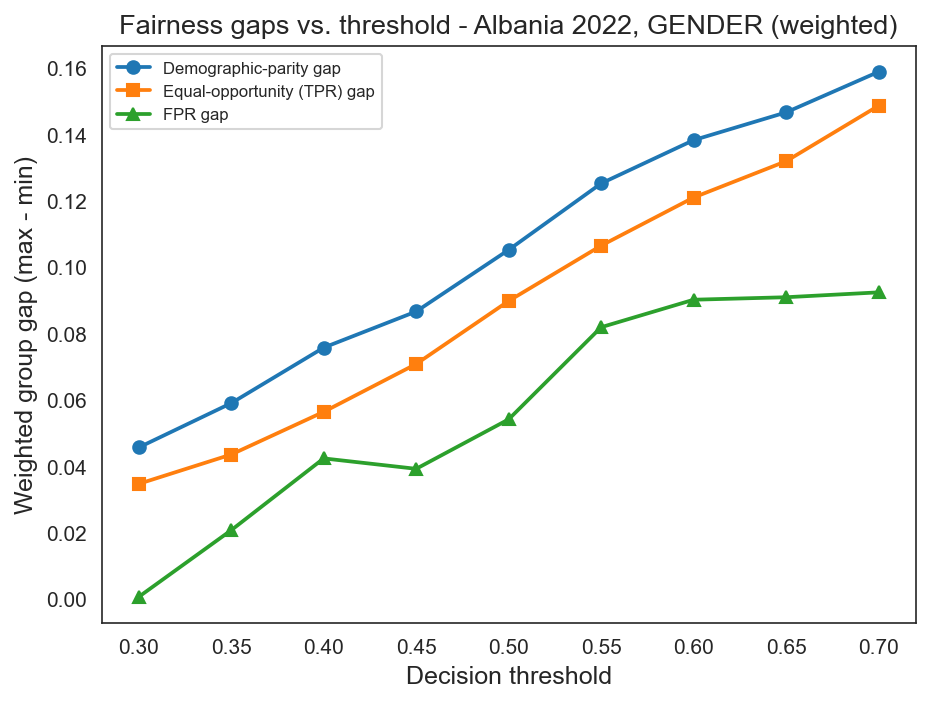

,threshold,parity_gap,opportunity_gap,fpr_gap
0,0.30,0.0456,0.0347,0.0006
1,0.35,0.0590,0.0435,0.0207
2,0.40,0.0757,0.0564,0.0423
3,0.45,0.0866,0.0708,0.0392
4,0.50,0.1052,0.0898,0.0541
5,0.55,0.1252,0.1065,0.0819
6,0.60,0.1383,0.1210,0.0902
7,0.65,0.1466,0.1319,0.0909
8,0.70,0.1588,0.1486,0.0924


In [8]:
from src.visualization.style import apply_publication_style
apply_publication_style()
sweep = threshold_sweep(audit, 'y_true', 'y_prob', 'GENDER', weight_col='W_FSTUWT')
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sweep['threshold'], sweep['parity_gap'], '-o', label='Demographic-parity gap')
ax.plot(sweep['threshold'], sweep['opportunity_gap'], '-s', label='Equal-opportunity (TPR) gap')
ax.plot(sweep['threshold'], sweep['fpr_gap'], '-^', label='FPR gap')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Weighted group gap (max - min)')
ax.set_title('Fairness gaps vs. threshold - Albania 2022, GENDER (weighted)')
ax.legend(fontsize=8); plt.show()
sweep.round(4)

## Conclusions & Interpretation

- **SES is the fairness fault line.** Weighted parity gap ≈ **0.48** and FPR gap ≈ **0.63** across SES quintiles — the bottom quintile is flagged at-risk ~91% of the time (selection rate 0.91, FPR 0.83) vs. ~43% for the top. Adding school-mean SES as a top feature does **not** fix this — school SES *is* SES, so the model doubly encodes the gradient and would act on it.
- **Gender gap shrank.** Vs. the student-only model the gender gaps dropped (parity 0.18→0.11, FPR 0.14→0.05) — school context absorbed part of the gender signal. Girls (group 1) still get a somewhat higher selection rate and FPR.
- **Immigrant status:** a large **FPR gap (~0.59)** — immigrant-background students are over-flagged among the truly proficient — though the immigrant groups are small and the FPR=1.0 cell is unstable; treat as a flag, not a precise estimate.
- **No free threshold.** The sweep shows moving the operating point shifts the gaps around rather than eliminating them — fairness here is structural (in the risk signal), not a threshold artefact. Genuine mitigation needs reweighting/constraints or group-aware calibration, not just a knob.
- **Deployment caveat:** a naïvely deployed screener would concentrate false alarms on low-SES and immigrant-background students, and the school-context features tie a student's score to *where* they study. Any real use needs an explicit fairness constraint. Matches `fairness_audit_2022.json` and figure E1.